# Image Preprocessing with OpenCV
This notebook covers foundational digital image operations used in computer vision pipelines.


Topics include I/O and data handling, color-space conversion (RGB/grayscale), 3D intensity distribution analysis, and pseudocolor colormaps for contrast perception.

In [1]:
import cv2
from matplotlib import pyplot as plt
import os

### Data Loading and Color-Space Conversion
The script downloads a test image from an external repository and skips the download if the file already exists.


OpenCV's `imread` loads images in **BGR** (Blue-Green-Red) order by default. Matplotlib expects **RGB**, so a conversion step is required for correct display.

--2026-03-18 00:15:07--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/01_Intro/mandril.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77244 (75K) [image/jpeg]
Saving to: 'mandril.jpg'

     0K .......... .......... .......... .......... .......... 66%  991K 0s
    50K .......... .......... .....                           100% 9,65M=0,05s

2026-03-18 00:15:07 (1,39 MB/s) - 'mandril.jpg' saved [77244/77244]



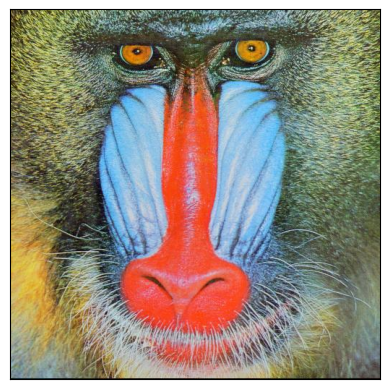

In [2]:
if not os.path.exists("mandril.jpg") :
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/01_Intro/mandril.jpg

I = cv2.imread('mandril.jpg')
I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)

plt.imshow(I)
plt.xticks([]), plt.yticks([])
plt.show()


### Grayscale Conversion
Most image analysis and feature-detection algorithms operate on single-channel grayscale images. This reduces computational cost while preserving shape and structure.

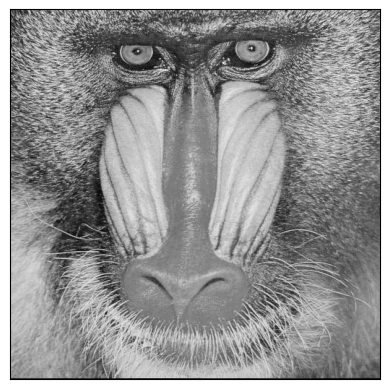

In [3]:
IG = cv2.cvtColor(I, cv2.COLOR_RGB2GRAY)
plt.imshow(IG)
plt.xticks([]), plt.yticks([])
plt.gray()
plt.show()


### Persisting Processed Data
The processed grayscale image is exported as lossless `.png` for reuse in downstream vision modules.

In [4]:
cv2.imwrite('mandril_gray.png', IG)

True

### Image as a 2D Function $L(x,y)$
A grayscale image can be modeled as a discrete 2D function where $x$ and $y$ are pixel coordinates and $L(x,y)$ is intensity (typically in $[0, 255]$).


Below, a NumPy mesh grid renders a 3D intensity surface—useful for inspecting local extrema and noise.

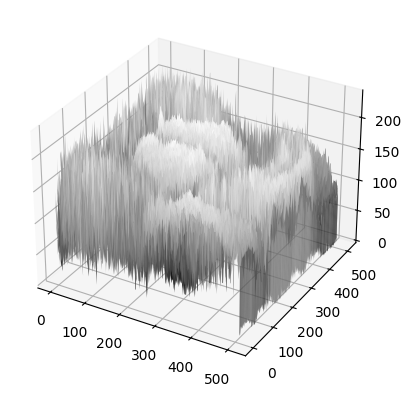

In [5]:
import numpy as np

# create grid
xx, yy = np.mgrid[0:IG.shape[0], 0:IG.shape[1]]

# create the figure
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xx, yy, IG ,rstride=3, cstride=3, cmap=plt.get_cmap('gray'),
        linewidth=0)

# show it
plt.show()

### Intensity Profiles (Image Cross-Sections)
When designing control logic or vision filters, inspecting brightness gradients helps. Here we extract and plot 1D intensity profiles along a fixed row and column.

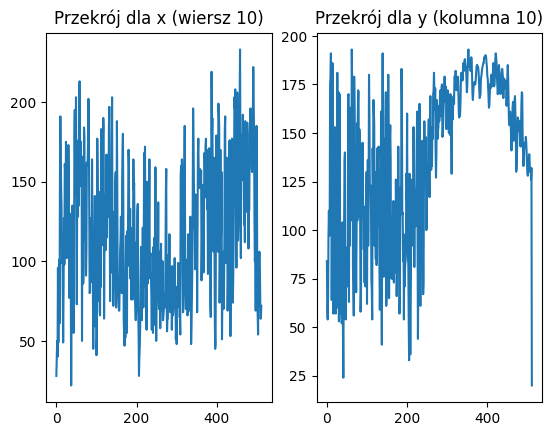

In [6]:
S = IG[10,:]
Y = IG[:,10]
f, (ax1,ax2) = plt.subplots(1,2)
ax1.set_title('Cross-section along x (row 10)')
ax1.plot(S)
ax2.set_title('Cross-section along y (column 10)')
ax2.plot(Y)
plt.show()

### Pseudocolor Mapping (Colormaps)
Pseudocolor colormaps (e.g. `cool`, `GnBu`, `autumn`) are widely used in medical, thermal, and satellite imaging.


LUT-based coloring does not add information to a single-channel image, but it makes subtle contrast differences easier for the human visual system to interpret.

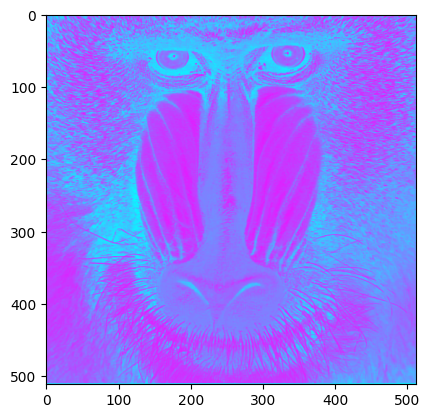

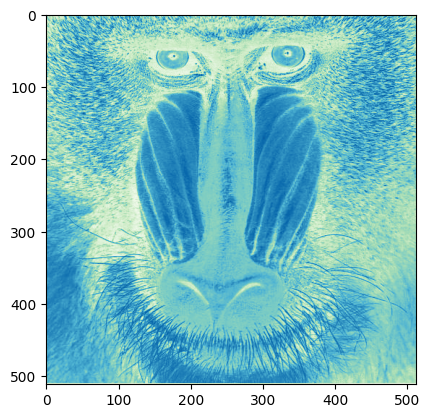

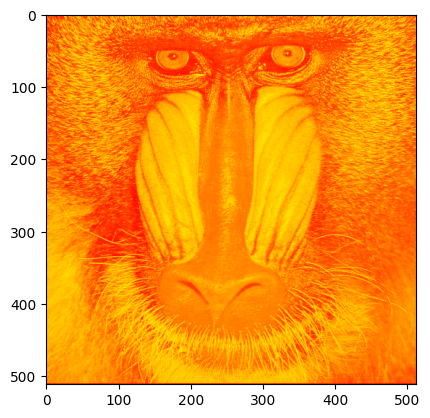

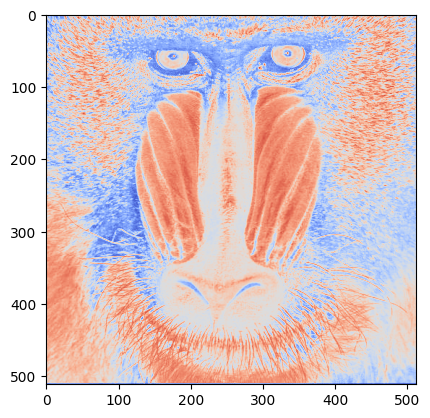

In [7]:
plt.imshow(IG, cmap=plt.get_cmap('cool'))
plt.show()

plt.imshow(IG, cmap=plt.get_cmap('GnBu'))
plt.show()

plt.imshow(IG, cmap=plt.get_cmap('autumn'))
plt.show()

plt.imshow(IG, cmap=plt.get_cmap('coolwarm'))
plt.show()